## Q3: What is the financial cost of fraud, and how much does our model save?

We use Logistic Regression with PCA (Model 1) because its imperfect recall creates a meaningful before/after contrast — missed fraud cases have a real dollar cost that threshold tuning directly reduces.

**Approach:**
1. Same feature engineering and PCA pipeline as Model_PCA_LR.ipynb (C=1.0, 95% variance)
2. Apply two thresholds: default (0.5) and optimized (max recall @ precision ≥ 10%)
3. Translate TP, FP, FN into dollar values using actual transaction amounts
4. Compare net financial benefit before and after threshold tuning

**Cost assumptions:**
- **Missed fraud (FN):** Full transaction amount is lost
- **Caught fraud (TP):** Full transaction amount is saved
- **False alarm (FP):** $25 investigator review cost per flagged transaction

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix,
    average_precision_score,
    precision_recall_curve,
)
import warnings
warnings.filterwarnings('ignore')

INVESTIGATOR_COST = 25  # $ per false alarm reviewed

## 1. Load Data & Feature Engineering

Identical pipeline to Model_PCA_LR.ipynb.

In [43]:
df = pd.read_csv('Financial_Fraud_dataset.csv')

df = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()
df['type_encoded']     = (df['type'] == 'TRANSFER').astype(int)
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']
df['origDrained']      = ((df['newbalanceOrig'] == 0) & (df['oldbalanceOrg'] > 0)).astype(int)
df['destUnchanged']    = (df['newbalanceDest'] == df['oldbalanceDest']).astype(int)
df['log_amount']       = np.log1p(df['amount'])

FEATURES = [
    'log_amount',
    'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest',
    'errorBalanceOrig', 'errorBalanceDest',
    'origDrained', 'destUnchanged',
    'type_encoded',
]

split_step = int(df['step'].quantile(0.80))
train_df   = df[df['step'] <= split_step]
test_df    = df[df['step'] >  split_step]

X_train = train_df[FEATURES].values
y_train = train_df['isFraud'].values
X_test  = test_df[FEATURES].values
y_test  = test_df['isFraud'].values

amounts_test = test_df['amount'].values

print(f"Test set: {len(y_test):,} transactions | Fraud: {y_test.sum():,} ({y_test.mean()*100:.4f}%)")
print(f"Total fraud value in test set: ${amounts_test[y_test == 1].sum():,.2f}")
print(f"Average fraud transaction:     ${amounts_test[y_test == 1].mean():,.2f}")

Test set: 552,504 transactions | Fraud: 4,258 (0.7707%)
Total fraud value in test set: $6,702,594,765.36
Average fraud transaction:     $1,574,118.08


## 2. Train Logistic Regression Pipeline

StandardScaler → PCA (95% variance) → Logistic Regression with C=1.0.

In [33]:
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_train), size=min(100_000, len(X_train)), replace=False)
X_sample = StandardScaler().fit_transform(X_train[sample_idx])
pca_full = PCA().fit(X_sample)
cumulative = np.cumsum(pca_full.explained_variance_ratio_)
N_COMPONENTS = int(np.argmax(cumulative >= 0.95)) + 1
print(f"PCA components for 95% variance: {N_COMPONENTS}")

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=N_COMPONENTS)),
    ('clf', LogisticRegression(
        C=2.0, class_weight='balanced', max_iter=1000, solver='lbfgs', random_state=42)),
])

print("Training pipeline...")
pipeline.fit(X_train, y_train)
y_proba = pipeline.predict_proba(X_test)[:, 1]
print(f"PR-AUC: {average_precision_score(y_test, y_proba):.4f}")

PCA components for 95% variance: 8
Training pipeline...
PR-AUC: 0.9240


## 3. Define Thresholds

Three thresholds to compare:
- **Recall-priority:** maximize recall subject to precision ≥ 10%
- **F1-priority:** maximize F1 (balances precision and recall equally)

In [34]:
precision_curve, recall_curve, thresholds = precision_recall_curve(y_test, y_proba)

# Recall-priority: maximize recall where precision >= 10%
PRECISION_FLOOR = 0.10
valid         = precision_curve[:-1] >= PRECISION_FLOOR
recall_thresh = thresholds[np.argmax(recall_curve[:-1] * valid)]

# F1-priority: maximize F1
f1_scores  = 2 * (precision_curve[:-1] * recall_curve[:-1]) / (precision_curve[:-1] + recall_curve[:-1] + 1e-9)
f1_thresh  = thresholds[np.argmax(f1_scores)]

y_pred_recall = (y_proba >= recall_thresh).astype(int)
y_pred_f1     = (y_proba >= f1_thresh).astype(int)

print(f"Recall-priority threshold: {recall_thresh:.4f}")
print(f"F1-priority threshold:     {f1_thresh:.4f}")

Recall-priority threshold: 0.4004
F1-priority threshold:     0.8659


## 4. Financial Impact — Recall-Priority vs F1-Priority

For each threshold:
- **Money saved:** sum of actual transaction amounts for correctly caught fraud (TP)
- **Money lost:** sum of actual transaction amounts for missed fraud (FN)
- **Investigation cost:** number of false alarms × $25 per review
- **Net benefit:** money saved − investigation cost

In [35]:
def financial_summary(y_true, y_pred, amounts, investigator_cost, label):
    tn, fp, fn, tp_count = confusion_matrix(y_true, y_pred).ravel()

    tp_mask = (y_true == 1) & (y_pred == 1)
    fn_mask = (y_true == 1) & (y_pred == 0)

    money_saved = amounts[tp_mask].sum()
    money_lost  = amounts[fn_mask].sum()
    invest_cost = fp * investigator_cost
    net_benefit = money_saved - money_lost - invest_cost

    print(f"{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    print(f"  Fraud cases caught (TP):       {tp_count:,}")
    print(f"  Fraud cases missed (FN):       {fn:,}")
    print(f"  False alarms (FP):             {fp:,}")
    print(f"  Recall:    {tp_count / (tp_count + fn):.4f}")
    print(f"  Precision: {tp_count / (tp_count + fp):.4f}")
    print()
    print(f"  Money saved  (caught fraud):   ${money_saved:>15,.2f}")
    print(f"  Money lost   (missed fraud):  -${money_lost:>15,.2f}")
    print(f"  Investigation cost ($25/FP):  -${invest_cost:>15,.2f}")
    print(f"  {'─'*40}")
    print(f"  Net benefit:                   ${net_benefit:>15,.2f}")
    print()

    return {
        'label': label,
        'tp': tp_count, 'fn': fn, 'fp': fp,
        'money_saved': money_saved,
        'money_lost':  money_lost,
        'invest_cost': invest_cost,
        'net_benefit': net_benefit,
    }

results_recall = financial_summary(y_test, y_pred_recall, amounts_test, INVESTIGATOR_COST, f'Original Recall Priority  (threshold={recall_thresh:.4f})')
results_f1     = financial_summary(y_test, y_pred_f1,     amounts_test, INVESTIGATOR_COST, f'F1-Priority      (threshold={f1_thresh:.4f})')

  Original Recall Priority  (threshold=0.4004)
  Fraud cases caught (TP):       4,245
  Fraud cases missed (FN):       13
  False alarms (FP):             38,205
  Recall:    0.9969
  Precision: 0.1000

  Money saved  (caught fraud):   $6,631,766,030.46
  Money lost   (missed fraud):  -$  70,828,734.90
  Investigation cost ($25/FP):  -$     955,125.00
  ────────────────────────────────────────
  Net benefit:                   $6,559,982,170.56

  F1-Priority      (threshold=0.8659)
  Fraud cases caught (TP):       3,422
  Fraud cases missed (FN):       836
  False alarms (FP):             259
  Recall:    0.8037
  Precision: 0.9296

  Money saved  (caught fraud):   $6,539,853,165.11
  Money lost   (missed fraud):  -$ 162,741,600.25
  Investigation cost ($25/FP):  -$       6,475.00
  ────────────────────────────────────────
  Net benefit:                   $6,377,105,089.86



## 5. Side-by-Side Comparison Chart

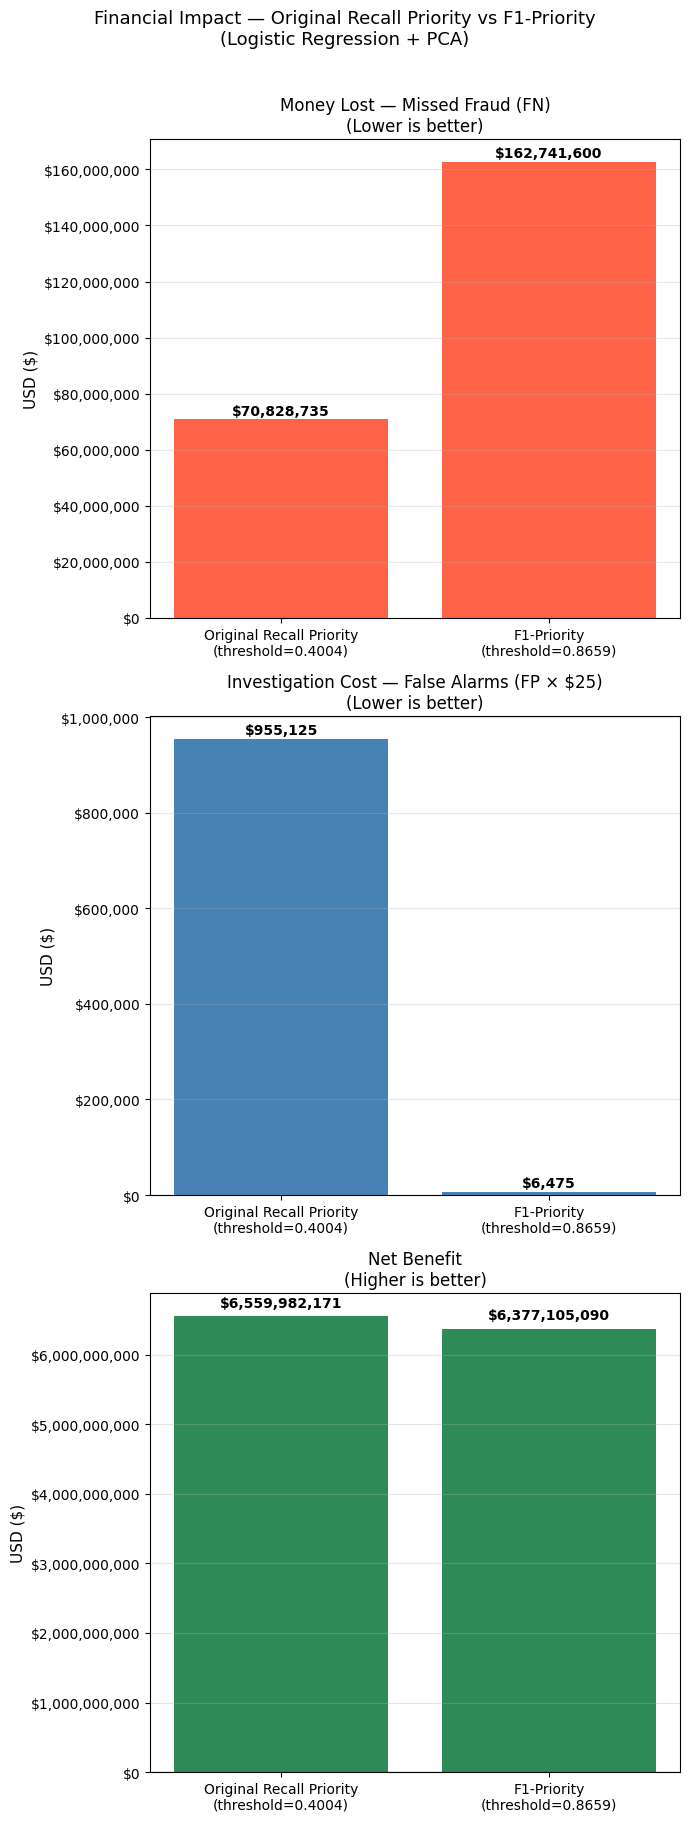

Net benefit difference: $182,877,080.70 in favour of Original Recall Priority


In [36]:
labels   = [f'Original Recall Priority\n(threshold={recall_thresh:.4f})', f'F1-Priority\n(threshold={f1_thresh:.4f})']
lost     = [results_recall['money_lost'],   results_f1['money_lost']]
inv_cost = [results_recall['invest_cost'],  results_f1['invest_cost']]
net      = [results_recall['net_benefit'],  results_f1['net_benefit']]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(7, 18))

# Chart 1: Money lost from missed fraud (FN)
ax1.bar(labels, lost, color='tomato', width=0.8)
ax1.set_ylabel('USD ($)', fontsize=11)
ax1.set_title('Money Lost — Missed Fraud (FN)\n(Lower is better)', fontsize=12)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(lost):
    ax1.text(i, v + max(lost) * 0.01, f'${v:,.0f}', ha='center', fontsize=10, fontweight='bold')

# Chart 2: Investigation cost from false alarms (FP)
ax2.bar(labels, inv_cost, color='steelblue', width=0.8)
ax2.set_ylabel('USD ($)', fontsize=11)
ax2.set_title('Investigation Cost — False Alarms (FP × $25)\n(Lower is better)', fontsize=12)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax2.grid(axis='y', alpha=0.3)
for i, v in enumerate(inv_cost):
    ax2.text(i, v + max(inv_cost) * 0.01, f'${v:,.0f}', ha='center', fontsize=10, fontweight='bold')

# Chart 3: Net benefit
colors_net = ['seagreen' if v >= 0 else 'firebrick' for v in net]
ax3.bar(labels, net, color=colors_net, width=0.8)
ax3.set_ylabel('USD ($)', fontsize=11)
ax3.set_title('Net Benefit\n(Higher is better)', fontsize=12)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax3.axhline(y=0, color='black', linewidth=0.8)
ax3.grid(axis='y', alpha=0.3)
for i, v in enumerate(net):
    ax3.text(i, v + max(abs(n) for n in net) * 0.02, f'${v:,.0f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Financial Impact — Original Recall Priority vs F1-Priority\n(Logistic Regression + PCA)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

diff = results_recall['net_benefit'] - results_f1['net_benefit']
winner = 'Original Recall Priority' if diff > 0 else 'F1-Priority'
print(f"Net benefit difference: ${abs(diff):,.2f} in favour of {winner}")

## 6. Threshold Sweep — Full Precision/Recall Tradeoff

We test thresholds from 0.05 up to the F1-optimal threshold in steps of 0.05, storing recall, precision, TNR, FNR, and full financial impact at each point.

This directly answers: **how do you decide on the right threshold?** The net benefit curve shows the financially optimal point — rather than picking recall-priority or F1 arbitrarily, we let the data tell us where the tradeoff maximizes value.

In [37]:
sweep_thresholds = np.arange(0.05, f1_thresh + 0.001, 0.05)

sweep_results = []
for thresh in sweep_thresholds:
    y_pred_t = (y_proba >= thresh).astype(int)
    tn, fp, fn, tp_count = confusion_matrix(y_test, y_pred_t).ravel()

    tp_mask = (y_test == 1) & (y_pred_t == 1)
    fn_mask = (y_test == 1) & (y_pred_t == 0)

    money_saved = amounts_test[tp_mask].sum()
    money_lost  = amounts_test[fn_mask].sum()
    invest_cost = fp * INVESTIGATOR_COST
    net_benefit = money_saved - money_lost - invest_cost

    recall    = tp_count / (tp_count + fn) if (tp_count + fn) > 0 else 0
    precision = tp_count / (tp_count + fp) if (tp_count + fp) > 0 else 0
    tnr       = tn / (tn + fp) if (tn + fp) > 0 else 0
    fnr       = fn / (fn + tp_count) if (fn + tp_count) > 0 else 0

    sweep_results.append({
        'threshold':               round(thresh, 4),
        'tp':                      tp_count,
        'fn':                      fn,
        'fp':                      fp,
        'tn':                      tn,
        'recall':                  recall,
        'precision':               precision,
        'tnr':                     tnr,
        'fnr':                     fnr,
        'saved_from_caught ($)':   money_saved,
        'lost_from_missed ($)':    money_lost,
        'cost_from_false_pos ($)': invest_cost,
        'net_benefit ($)':         net_benefit,
    })

sweep_df = pd.DataFrame(sweep_results)
display(sweep_df)

,threshold,tp,fn,fp,tn,recall,precision,tnr,fnr,saved_from_caught ($),lost_from_missed ($),cost_from_false_pos ($),net_benefit ($)
0,0.05,4246,12,135352,412894,0.997182,0.030416,0.753118,0.002818,6.631900e+09,7.069510e+07,3383800,6.557821e+09
1,0.10,4245,13,104544,443702,0.996947,0.039020,0.809312,0.003053,6.631766e+09,7.082873e+07,2613600,6.558324e+09
2,0.15,4245,13,87256,460990,0.996947,0.046393,0.840845,0.003053,6.631766e+09,7.082873e+07,2181400,6.558756e+09
3,0.20,4245,13,74244,474002,0.996947,0.054084,0.864579,0.003053,6.631766e+09,7.082873e+07,1856100,6.559081e+09
4,0.25,4245,13,63464,484782,0.996947,0.062695,0.884242,0.003053,6.631766e+09,7.082873e+07,1586600,6.559351e+09
5,0.30,4245,13,54174,494072,0.996947,0.072665,0.901187,0.003053,6.631766e+09,7.082873e+07,1354350,6.559583e+09
6,0.35,4245,13,45960,502286,0.996947,0.084553,0.916169,0.003053,6.631766e+09,7.082873e+07,1149000,6.559788e+09
7,0.40,4245,13,38253,509993,0.996947,0.099887,0.930227,0.003053,6.631766e+09,7.082873e+07,956325,6.559981e+09
8,0.45,4245,13,31224,517022,0.996947,0.119682,0.943047,0.003053,6.631766e+09,7.082873e+07,780600,6.560157e+09
9,0.50,4244,14,24552,523694,0.996712,0.147382,0.955217,0.003288,6.631640e+09,7.095480e+07,613800,6.560071e+09


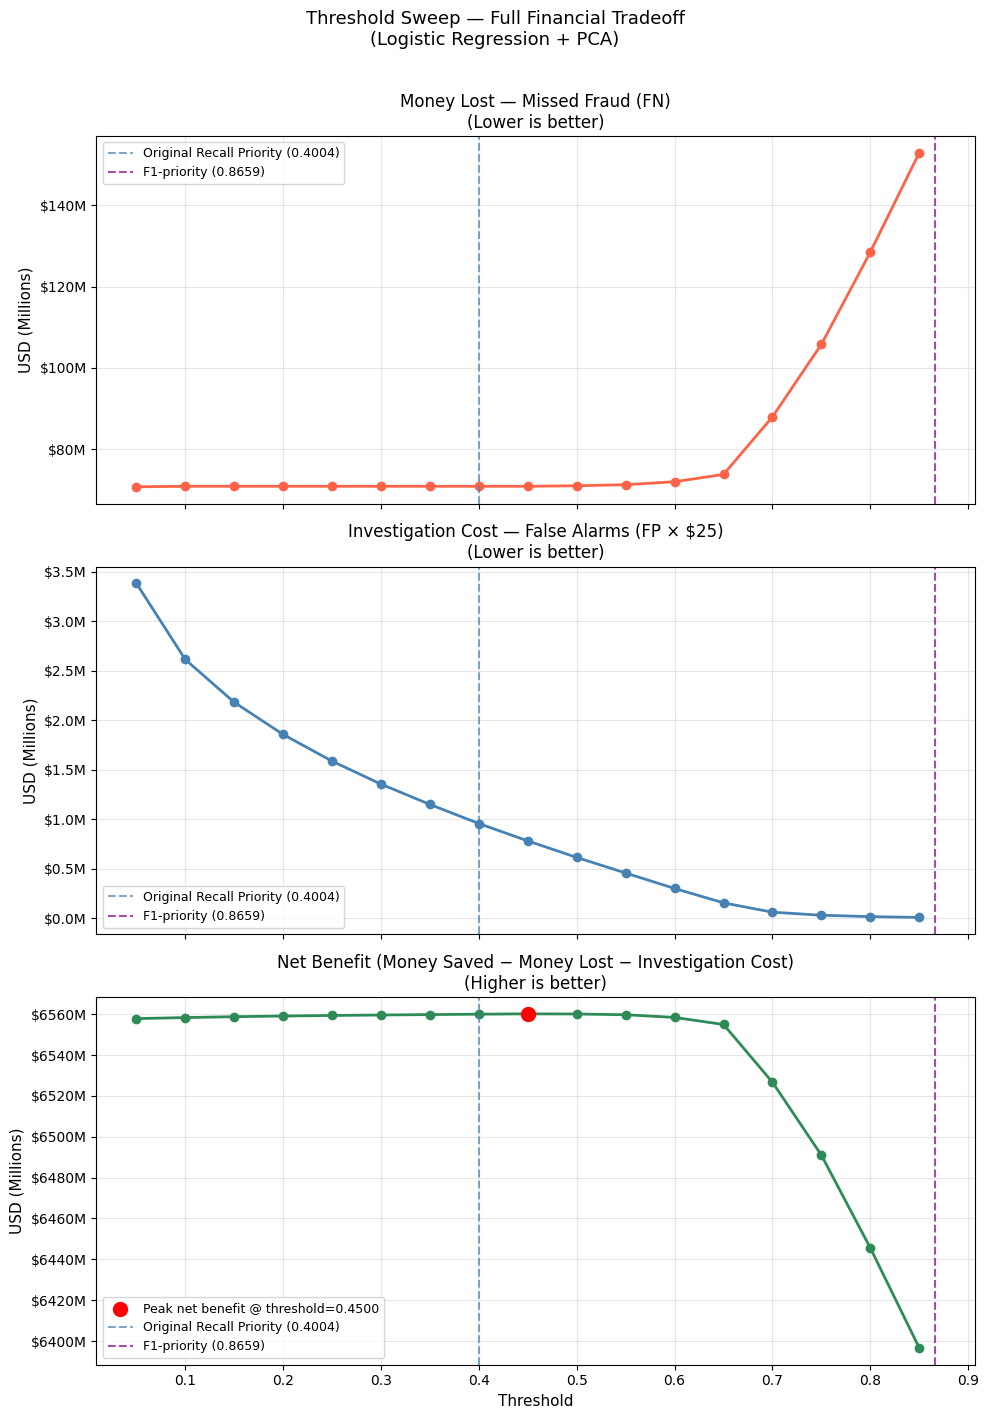

Peak net benefit: $6,560,156,695.56 at threshold=0.4500
  Recall:    0.9969  |  Precision: 0.1197  |  TNR: 0.9430  |  FNR: 0.0031
  Saved from caught fraud:   $6,631,766,030.46
  Lost from missed fraud:   -$  70,828,734.90
  Investigation cost:       -$     780,600.00


In [38]:
fig, axes = plt.subplots(3, 1, figsize=(10, 14), sharex=True)

x = sweep_df['threshold']

# Chart 1: Money lost (FN cost)
axes[0].plot(x, sweep_df['lost_from_missed ($)'] / 1e6, color='tomato', marker='o', linewidth=2)
axes[0].set_ylabel('USD (Millions)', fontsize=11)
axes[0].set_title('Money Lost — Missed Fraud (FN)\n(Lower is better)', fontsize=12)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:.0f}M'))
axes[0].grid(alpha=0.3)
axes[0].axvline(x=recall_thresh, color='steelblue', linestyle='--', alpha=0.7, label=f'Original Recall Priority ({recall_thresh:.4f})')
axes[0].axvline(x=f1_thresh,     color='purple',    linestyle='--', alpha=0.7, label=f'F1-priority ({f1_thresh:.4f})')
axes[0].legend(fontsize=9)

# Chart 2: Investigation cost (FP cost)
axes[1].plot(x, sweep_df['cost_from_false_pos ($)'] / 1e6, color='steelblue', marker='o', linewidth=2)
axes[1].set_ylabel('USD (Millions)', fontsize=11)
axes[1].set_title('Investigation Cost — False Alarms (FP × $25)\n(Lower is better)', fontsize=12)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:.1f}M'))
axes[1].grid(alpha=0.3)
axes[1].axvline(x=recall_thresh, color='steelblue', linestyle='--', alpha=0.7, label=f'Original Recall Priority ({recall_thresh:.4f})')
axes[1].axvline(x=f1_thresh,     color='purple',    linestyle='--', alpha=0.7, label=f'F1-priority ({f1_thresh:.4f})')
axes[1].legend(fontsize=9)

# Chart 3: Net benefit
axes[2].plot(x, sweep_df['net_benefit ($)'] / 1e6, color='seagreen', marker='o', linewidth=2)
axes[2].set_ylabel('USD (Millions)', fontsize=11)
axes[2].set_title('Net Benefit (Money Saved − Money Lost − Investigation Cost)\n(Higher is better)', fontsize=12)
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:.0f}M'))
axes[2].set_xlabel('Threshold', fontsize=11)
axes[2].grid(alpha=0.3)

best_row = sweep_df.loc[sweep_df['net_benefit ($)'].idxmax()]
axes[2].scatter(best_row['threshold'], best_row['net_benefit ($)'] / 1e6,
                color='red', zorder=5, s=100,
                label=f'Peak net benefit @ threshold={best_row["threshold"]:.4f}')
axes[2].axvline(x=recall_thresh, color='steelblue', linestyle='--', alpha=0.7, label=f'Original Recall Priority ({recall_thresh:.4f})')
axes[2].axvline(x=f1_thresh,     color='purple',    linestyle='--', alpha=0.7, label=f'F1-priority ({f1_thresh:.4f})')
axes[2].legend(fontsize=9)

plt.suptitle('Threshold Sweep — Full Financial Tradeoff\n(Logistic Regression + PCA)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f"Peak net benefit: ${best_row['net_benefit ($)']:,.2f} at threshold={best_row['threshold']:.4f}")
print(f"  Recall:    {best_row['recall']:.4f}  |  Precision: {best_row['precision']:.4f}  |  TNR: {best_row['tnr']:.4f}  |  FNR: {best_row['fnr']:.4f}")
print(f"  Saved from caught fraud:   ${best_row['saved_from_caught ($)']:>15,.2f}")
print(f"  Lost from missed fraud:   -${best_row['lost_from_missed ($)']:>15,.2f}")
print(f"  Investigation cost:       -${best_row['cost_from_false_pos ($)']:>15,.2f}")